In [ ]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader,random_split
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.nn.modules.pooling import MaxPool2d
from torch.nn.modules.activation import ReLU

In [ ]:
import zipfile
import os
zip_ref = zipfile.ZipFile('/content/dataset-resized.zip', 'r')
zip_ref.extractall('/content/')
zip_ref.close()

# Assuming the unzipped folder will be named 'PlantVillage'
dataset_root = '/content/dataset-resized'


In [ ]:
transform=transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

In [ ]:
#Load Dataset
dataset=datasets.ImageFolder(
    root=dataset_root,
    transform=transform
)


In [ ]:
len(dataset)

2527

In [ ]:
class_name=dataset.classes
print(class_name)

['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [ ]:
#Train Test Split
train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    dataset,
    [train_size, val_size, test_size]
)

In [ ]:
train_set=DataLoader(train_dataset,batch_size=32,shuffle=True)
val_set=DataLoader(val_dataset,batch_size=32,shuffle=False)
test_set=DataLoader(test_dataset,batch_size=32,shuffle=False)

In [ ]:
#vizualization of data

import numpy as np
import matplotlib.pyplot as plt

for images, labels in train_set:
  for i in range(0,len(train_set)-20):

    image = images[i] # Get the first image from the batch
    label = labels[i] # Get the first label from the batch
    break # Exit after getting the first item

  mean = np.array([0.5, 0.5, 0.5])
  std = np.array([0.5, 0.5, 0.5])
  unnormalized_image = image.numpy().transpose((1, 2, 0))
  unnormalized_image = (unnormalized_image * std) + mean
  unnormalized_image = np.clip(unnormalized_image, 0, 1)

  # Display the image
  plt.figure(figsize=(6, 6))
  plt.imshow(unnormalized_image)
  plt.title(f"Class: {class_name[label]}")
  plt.axis('off')
  plt.show()

In [ ]:
print(f"Image dimensions: {image.shape}")

Image dimensions: torch.Size([3, 224, 224])


In [ ]:
# I have Use preTrained Model Insted of Custome Model
import torchvision.models as models
import torch.nn as nn
model = models.resnet50(pretrained=True)

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, len(class_name))

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 157MB/s]


In [ ]:
print(model.fc.in_features)

2048


In [ ]:

criterian=nn.CrossEntropyLoss()
optimizer=optim.Adam(model.parameters(),lr=0.001)

In [14]:
#train The Model
epochs=8
for epoch in range(epochs):
  for image,label in train_set:
    output=model(image)
    loss=criterian(output,label)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
  print(f"for {epoch+1} loss={loss}")

for 1 loss=1.6173471212387085
for 2 loss=1.8320307731628418
for 3 loss=0.5062035322189331
for 4 loss=0.8541993498802185
for 5 loss=0.44194307923316956
for 6 loss=0.15054422616958618
for 7 loss=1.2618656158447266
for 8 loss=0.07283403724431992


In [16]:
corr=0
total=0
with torch.no_grad():
  for image,label in test_set:
    output=model(image)
    _,predict=torch.max(output,1)
    total+=label.size(0)
    corr += (predict== label).sum().item()

  print("Acuuracy:",100*(corr/total))

Acuuracy: 75.0


In [18]:
torch.save(model.state_dict(), 'waste.pt')

In [17]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 16.5 MB/s eta 0:00:00


Predicted class: cardboard


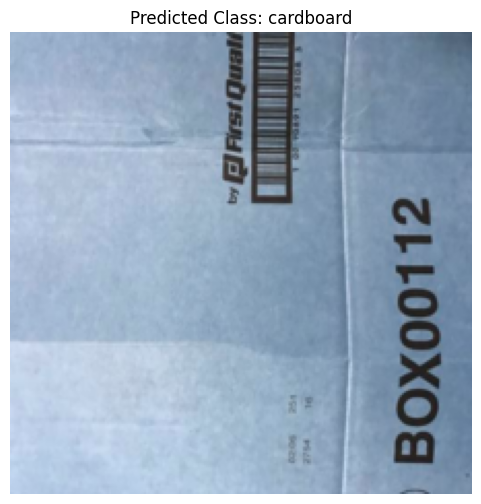

In [23]:
import cv2
import torch
import torchvision.models as models
import torch.nn as nn
from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np
class_name = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

img = cv2.imread("cardboard10.jpg")


model = models.resnet50(pretrained=False)
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, len(class_name))

model.load_state_dict(torch.load('waste.pt'))
model.eval()
# Define the same transformations used during training/validation
transform = transforms.Compose([
    transforms.ToPILImage(), # Convert OpenCV image (numpy array) to PIL Image
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Preprocess the input image
input_tensor = transform(img).unsqueeze(0) # Add a batch dimension

# Make prediction
with torch.no_grad():
    output = model(input_tensor)
    _, predicted_idx = torch.max(output, 1)
    predicted_class = class_name[predicted_idx.item()]

print(f"Predicted class: {predicted_class}")

unnormalized_image = input_tensor.squeeze(0).numpy().transpose((1, 2, 0))
mean = np.array([0.5, 0.5, 0.5])
std = np.array([0.5, 0.5, 0.5])
unnormalized_image = (unnormalized_image * std) + mean
unnormalized_image = np.clip(unnormalized_image, 0, 1)

plt.figure(figsize=(6, 6))
plt.imshow(unnormalized_image)
plt.title(f"Predicted Class: {predicted_class}")
plt.axis('off')
plt.show()